# **Bank Marketing Campaign Classification**
By : Yoshua Amazia Sigala

## **1. Business Problem Understanding**

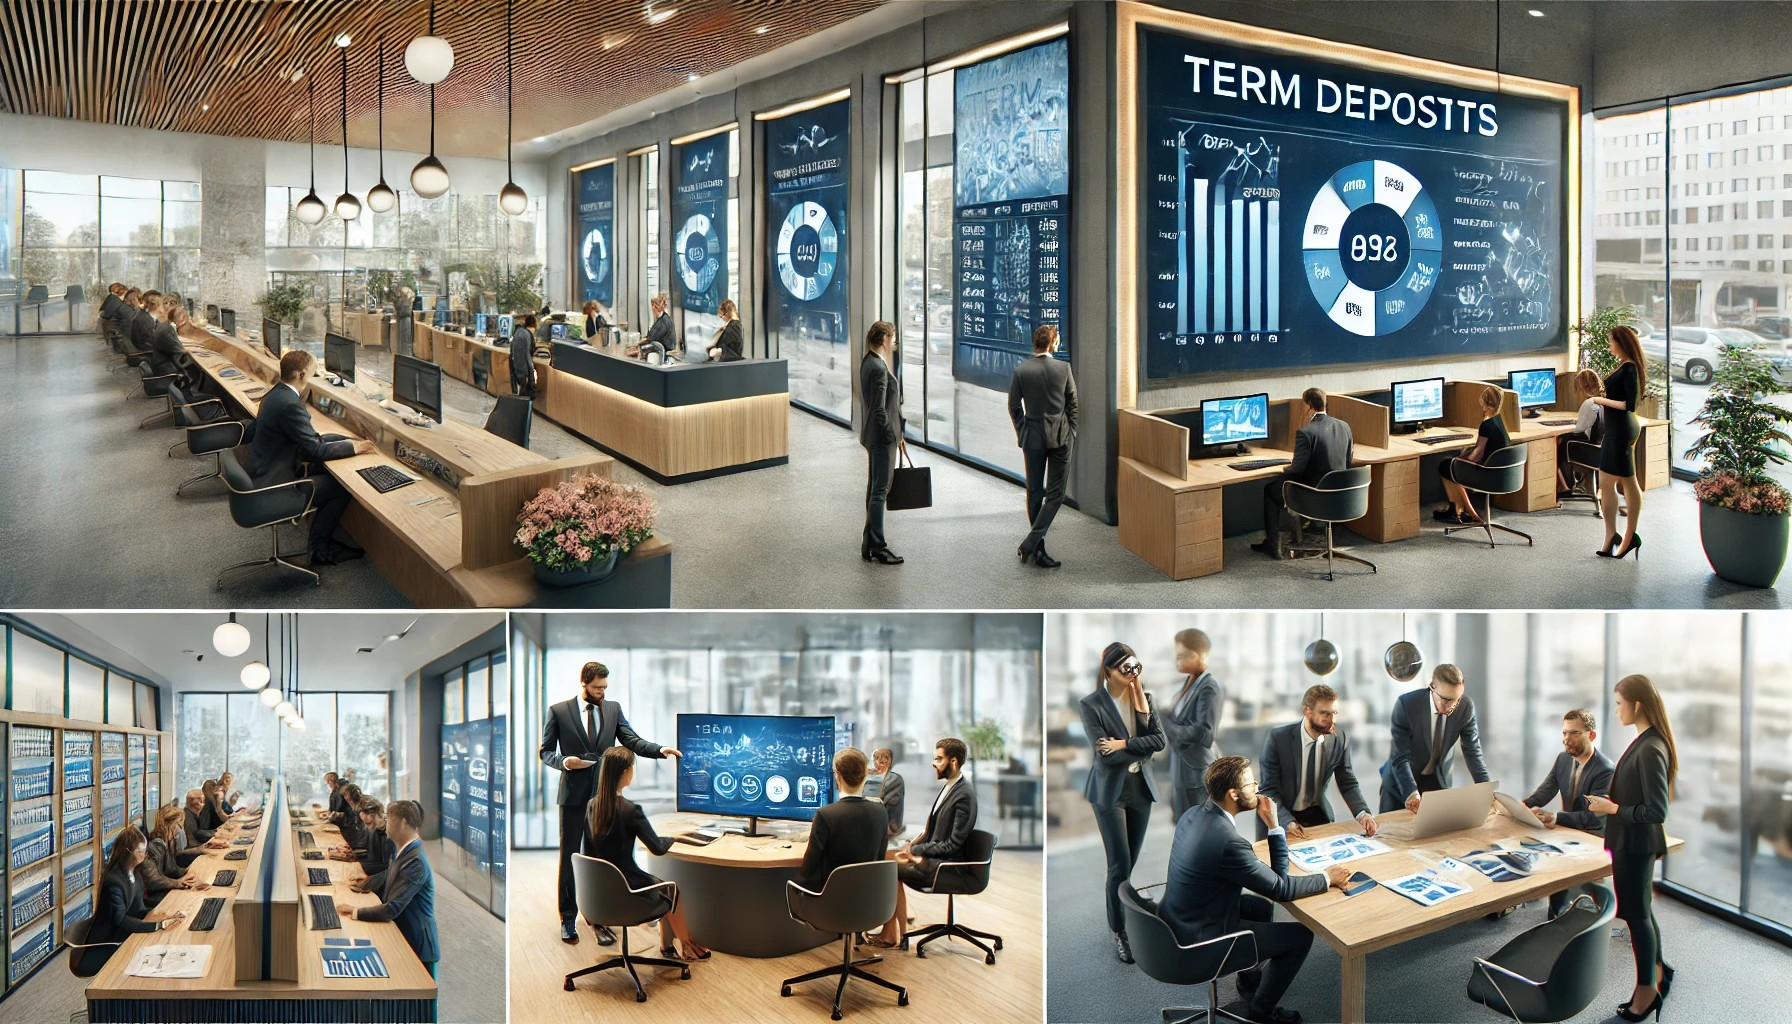

**📌Background**

In the competitive banking industry, attracting new customers is essential for growth, and term deposits are a popular financial product offering fixed returns. However, not all customers are inclined to open a term deposit, making it necessary for banks to conduct direct marketing campaigns, often through phone calls, to promote the product and persuade potential customers to subscribe.

To enhance the efficiency of these campaigns, a predictive model is needed to identify customers who are most likely to open a term deposit. By leveraging data-driven insights, banks can optimize their marketing strategies, reduce operational costs, and improve conversion rates, ultimately enhancing customer targeting and maximizing campaign success.

**📌Problem Statement**

The bank wants to improve the effectiveness of its term deposit marketing campaign by predicting whether a customer will subscribe to a term deposit or not based on customer demographics and previous marketing interactions. Currently, many customers contacted during the campaign do not subscribe, leading to unnecessary costs and reduced efficiency.

By using historical campaign data, we aim to develop a predictive model that helps identify high-potential customers for term deposits, enabling better marketing decisions and higher conversion rates.

**📌Goal**

Our objective as data scientists is to predict whether a customer will subscribe to a term deposit based on their profile and past interactions with marketing campaigns. This model will enable the bank to:

1. Optimize customer targeting by identifying potential customers more likely to subscribe.
2. Reduce marketing costs by minimizing unnecessary calls.
3. Improve conversion rates and overall campaign effectiveness.

**📌Target Variable**

`deposit` : whether the customer subscribed to a term deposit (yes/no).

- 1 (Positive Class) – The customer subscribed to a term deposit.
- 0 (Negative Class) – The customer did not subscribe to a term deposit.

**📌Analytical Approach**

1. Exploratory Data Analysis (EDA) – Understand customer segmentation, marketing trends, and feature importance.
2. Data Preprocessing & Feature Engineering – Handle missing values, encode categorical features.
3. Model Selection & Training – Apply classification models (Logistic Regression, Decision Tree, K-Neighbour, Random Forest, AdaBoost, Gradient Boosting, XGBoost and LightGBM).
4. Model Evaluation & Tuning – Optimize model performance using cross-validation and hyperparameter tuning.
5. Deployment Strategy – Provide actionable insights and recommendations to the marketing team.

**📌Metric Evaluation**

Since this is a binary classification problem, we consider the following metrics:

- Accuracy – Measures overall correctness of predictions.
- Precision – The proportion of predicted subscribers that actually subscribed. Helps reduce unnecessary marketing costs.
- Recall – The proportion of actual subscribers correctly identified. Helps avoid missing potential customers.
- F1-score – The harmonic mean of Precision & Recall, balancing false positives and false negatives.
- AUC-ROC (Area Under the Receiver Operating Characteristic Curve) – Measures the model’s ability to distinguish between subscribers and non-subscribers.

**🔹Best Metric for This Case**

- **F1-score** is crucial in this scenario as it balances both precision and recall, ensuring the model captures potential customers while minimizing excessive marketing costs. By prioritizing F1-score, the bank can maximize deposit conversions without significantly increasing False Positives or False Negatives. This helps in maintaining a profitable and cost-effective marketing strategy.

**🔹 Impact of True Positives & Negatives with Net Benefit Calculation**  

| Prediction vs Actual | Definition | Impact | Net Benefit Calculation |
| --- | --- | --- | --- |
| **True Positives (TP)** | Customers correctly predicted as deposit subscribers. | 🟢 **Direct marketing success** – Maximizes deposit acquisitions and revenue. | ✅ **Gain:** TP × Profit per TP = **TP × $1,650** |
| **False Positives (FP)** | Customers predicted to deposit but didn’t. | ❌ **Unnecessary marketing cost** – Leads to wasted outreach efforts. | 🔻 **Loss:** FP × Cost per FP = **FP × $396** |
| **True Negatives (TN)** | Customers correctly predicted as non-depositors. | ✅ **Marketing cost-saving** – Avoids contacting uninterested customers. | ⚖️ **Neutral:** TN × Profit per TN = **TN × $0** |
| **False Negatives (FN)** | Customers incorrectly predicted as non-depositors. | 🔴 **Missed opportunity** – Potential loss of customers who might have deposited. | 🔻 **Loss:** FN × Loss per FN = **FN × $1,650** |

  - *Source:* Average customer revenue from deposit accounts ([BankDirector](https://www.bankdirector.com/article/the-profitability-of-the-average-checking-account/))
  - *Source:* Average customer acquisition cost ([FirstPageSage](https://firstpagesage.com/seo-blog/average-customer-acquisition-cost-cac-in-banking/))
  
**📌 Final Net Benefit Formula:**  

$$
\text{Net Benefit} = (TP \times 1650) - (FP \times 396) - (FN \times 1650) + (TN \times 0)
$$


**📌Stakeholder**

The primary stakeholders for this analysis are the bank's marketing and sales teams, who are directly responsible for executing and optimizing the term deposit campaigns. By leveraging the insights from this analysis, these teams can identify and prioritize customers most likely to subscribe to a term deposit, allowing for more targeted and efficient marketing efforts. This not only reduces the costs associated with contacting uninterested customers but also improves campaign conversion rates, ensuring resources are allocated effectively.

**📌Feature Information**

**Customer Profile**

| Attribute | Data Type | Variable Type | Description |
| --- | --- | --- | --- |
| age | Integer | Numeric (Continuous) | Age of the customer. |
| job | Text | Categorical (Nominal) | Type of job the customer has (e.g., admin, self-employed, services, housemaid, etc.). |
| balance | Integer | Numeric (Continuous) | The customer's bank balance. |
| housing | Text | Categorical (Nominal) | Whether the customer has a housing loan (`yes`/`no`). |
| loan | Text | Categorical (Nominal) | Whether the customer has a personal loan (`yes`/`no`). |

**Campaign Data**

| Attribute | Data Type | Variable Type | Description |
| --- | --- | --- | --- |
| contact | Text | Categorical (Nominal) | Contact communication type (`cellular`, `telephone`). |
| month | Text | Categorical (Ordinal) | Last contact month of the year (e.g., `jan`, `feb`, `mar`, etc.). |
| campaign | Integer | Numeric (Discrete) | Number of times a customer was contacted during the current campaign. |
| pdays | Integer | Numeric (Discrete) | Number of days since the customer was last contacted since the previous campaign (`-1` means not previously contacted). |
| poutcome | Text | Categorical (Nominal) | Outcome of the previous marketing campaign (`success`, `failure`, `unknown`). |
| deposit | Text | Categorical (Binary) | Target variable: whether the customer subscribed to a term deposit (`yes`/`no`). |


## **2.1. Data Cleaning**

Before continue to Data Analysis, we need to check the data for any missing value, duplicates, and drop any unnecessary column.

### Import Library

In [3]:
# pip install category_encoders
# pip install shap

In [4]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection and Classification Model
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import fbeta_score
from sklearn.metrics import RocCurveDisplay
from sklearn.feature_selection import SelectFromModel

# Imbalance Dataset
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Save model
import joblib

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# # Mount Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Set max columns
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

### Load Dataset

In [5]:
df = pd.read_csv('data_bank_marketing_campaign.csv')
df

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
7808,62,housemaid,2,no,no,cellular,nov,1,-1,unknown,yes
7809,48,housemaid,5473,no,no,cellular,feb,2,184,success,yes
7810,36,unknown,179,no,no,cellular,aug,8,-1,unknown,no
7811,31,admin.,54,yes,no,cellular,nov,1,-1,unknown,no


In [6]:
df.shape

(7813, 11)

The dataset consist of 7813 rows with 11 columns

In [7]:
df.describe()

,age,balance,campaign,pdays
count,7813.000000,7813.000000,7813.000000,7813.000000
mean,41.257264,1512.448611,2.519775,51.408550
std,11.919710,3089.291831,2.727001,108.072739
min,18.000000,-6847.000000,1.000000,-1.000000
25%,32.000000,127.000000,1.000000,-1.000000
50%,39.000000,549.000000,2.000000,-1.000000
75%,49.000000,1684.000000,3.000000,40.000000
max,95.000000,66653.000000,63.000000,854.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


In [9]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,age,int64,0,0.0,75,"[22, 88]"
1,job,object,0,0.0,12,"[self-employed, technician]"
2,balance,int64,0,0.0,3153,"[3105, -438]"
3,housing,object,0,0.0,2,"[no, yes]"
4,loan,object,0,0.0,2,"[no, yes]"
5,contact,object,0,0.0,3,"[unknown, telephone]"
6,month,object,0,0.0,12,"[jun, jul]"
7,campaign,int64,0,0.0,32,"[10, 25]"
8,pdays,int64,0,0.0,422,"[236, 20]"
9,poutcome,object,0,0.0,4,"[success, failure]"


All the column inside the dataset contains relevant information therefore no columns are needed to be removed.

In [10]:
df.isnull().sum()

age         0
job         0
balance     0
housing     0
loan        0
contact     0
month       0
campaign    0
pdays       0
poutcome    0
deposit     0
dtype: int64

In [11]:
df.duplicated().sum()

8

In [12]:
df.drop_duplicates(inplace=True)

There's only 8 duplicated data and no missing value. Now we proceed to check missing values

### Check Missing Values

In [13]:
df.columns

Index(['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month',
       'campaign', 'pdays', 'poutcome', 'deposit'],
      dtype='object')

In [14]:
columns = ['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month',
       'campaign', 'pdays', 'poutcome', 'deposit']

for col in columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for age:
age
31    351
32    344
30    328
35    324
33    317
     ... 
93      2
86      2
90      2
92      1
95      1
Name: count, Length: 75, dtype: int64


Value counts for job:
job
management       1789
blue-collar      1343
technician       1289
admin.            936
services          658
retired           540
self-employed     280
unemployed        249
student           247
entrepreneur      236
housemaid         184
unknown            54
Name: count, dtype: int64


Value counts for balance:
balance
0       539
1        28
3        21
2        20
5        17
       ... 
1920      1
4101      1
824       1
4654      1
5473      1
Name: count, Length: 3153, dtype: int64


Value counts for housing:
housing
no     4136
yes    3669
Name: count, dtype: int64


Value counts for loan:
loan
no     6781
yes    1024
Name: count, dtype: int64


Value counts for contact:
contact
cellular     5623
unknown      1636
telephone     546
Name: count, dtype: int64


Value counts for

In [15]:
columns = ['job','contact']

for col in columns:
    print(f"Value counts for {col}:")
    display(df[col].value_counts())
    print("\n")

Value counts for job:


job
management       1789
blue-collar      1343
technician       1289
admin.            936
services          658
retired           540
self-employed     280
unemployed        249
student           247
entrepreneur      236
housemaid         184
unknown            54
Name: count, dtype: int64



Value counts for contact:


contact
cellular     5623
unknown      1636
telephone     546
Name: count, dtype: int64

In [16]:
# Check proportion
columns = ['job', 'contact']

for col in columns:
    print(f"Value counts for {col}:")
    display(df[col].value_counts(normalize=True))
    print('\n')

Value counts for job:


job
management       0.229212
blue-collar      0.172069
technician       0.165151
admin.           0.119923
services         0.084305
retired          0.069186
self-employed    0.035874
unemployed       0.031903
student          0.031646
entrepreneur     0.030237
housemaid        0.023575
unknown          0.006919
Name: proportion, dtype: float64



Value counts for contact:


contact
cellular     0.720436
unknown      0.209609
telephone    0.069955
Name: proportion, dtype: float64

For some columns like `job` and `contact`, unknown represents missing or incomplete data, so it should be set to NaN and imputed to preserve data integrity.

However, for `poutcome`, unknown carries a meaning ( no previous campaign outcome) and should remain for analysis rather than being treated as missing.

## **2.2. Exploratory Data Analysis**

### Univariate Analysis
Understand the distribution of individual features.

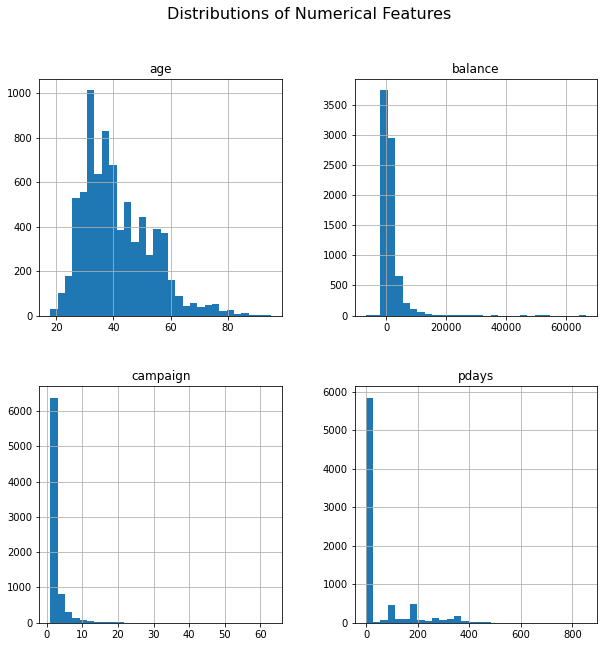

In [17]:
# Plot histograms for numerical features
numerical_features = ['age', 'balance', 'campaign', 'pdays']
df[numerical_features].hist(bins=30, figsize=(10, 10))
plt.suptitle('Distributions of Numerical Features', fontsize=16)
plt.show()

Intepretation for each visualization:
1. `age`:
    - Slightly right-skewed.
    - Most customers are aged 20-50, peaking in the 30s and 40s.
    - Few outliers above 80 years.

2. `balance`:
    - Highly right-skewed.
    - Most balances are close to 0.
    - Few customers have extremely high balances (>20,000), indicating outliers.

3. `campaign`:
    - Heavily right-skewed.
    - Majority contacted 1-2 times.
    - Rare cases with >10 contacts, extreme outliers above 40.

4. `pdays`:
    - Highly right-skewed.
    - Many values near 0, suggesting recent/no prior contact.
    - Few values >200 days, with extreme outliers >800 days.

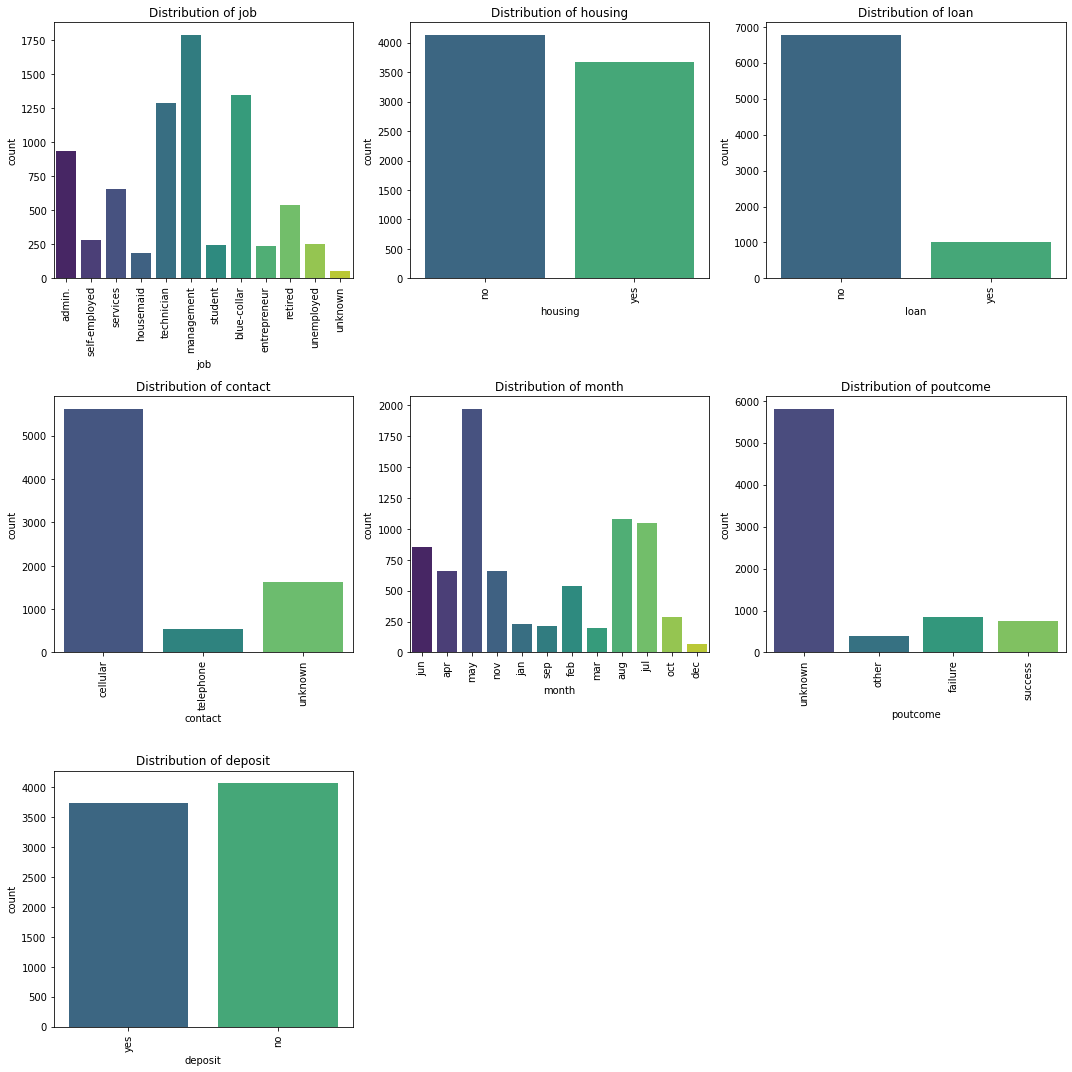

In [18]:
# Plot histograms for categorical features
categorical_features = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=df, x=feature, ax=axes[i], hue=feature, palette='viridis')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=90)

# Remove any unused subplots
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- `job` : Most customers are in blue-collar, management, and technician roles, with some entries being unknown.
- `housing` : Slightly more customers do not have housing loans (no), which might indicate more disposable income.
- `loan` : Most customers do not have personal loans (no), with only a small proportion having loans (yes).
- `contact` : The majority were contacted via cellular, followed by telephone, with some marked as unknown.
- `month` : Peak contact months are may, jul, aug, and nov, while jan, feb, and dec have low contact rates.
- `poutcome` : Most entries are unknown, indicating new customers, while success in previous campaigns likely impacts deposits.
- `deposit` : Slightly more customers did not subscribe (no), highlighting the challenge of conversion in marketing.

### **Bivariate Analysis**

Bivariate analysis explores the relationship between independent features and the target variable `deposit`. This helps identify patterns and correlations that are critical for predictive modeling.

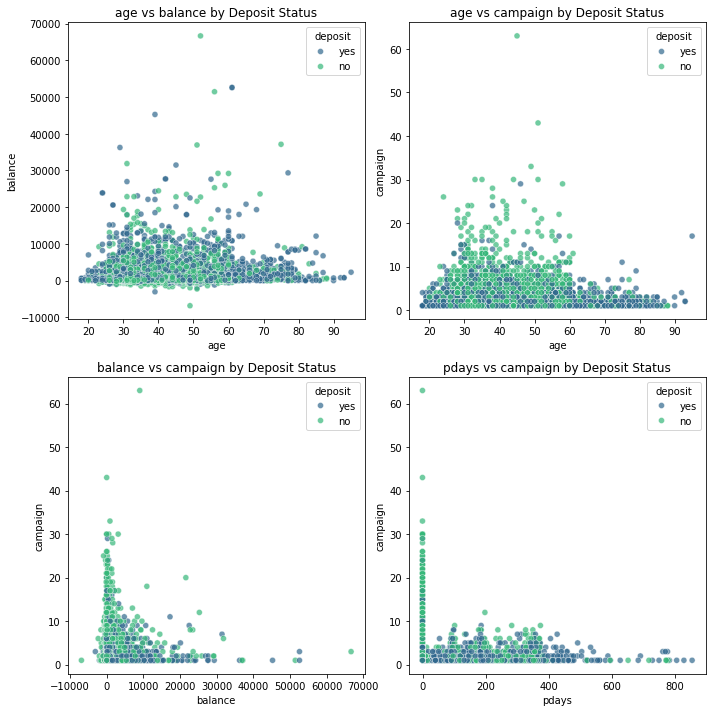

In [19]:
scatter_pairs = [
    ('age', 'balance'),       # Relationship between age and balance
    ('age', 'campaign'),      # Age vs number of contacts
    ('balance', 'campaign'),  # Balance vs number of contacts
    ('pdays', 'campaign')     # Previous contact days vs campaign calls
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axes = axes.flatten()

# Visualize scatter plots with 'deposit' as hue
for i, (x_feature, y_feature) in enumerate(scatter_pairs):
    sns.scatterplot(data=df, x=x_feature, y=y_feature, hue='deposit', palette='viridis', alpha=0.7, ax=axes[i])
    axes[i].set_title(f'{x_feature} vs {y_feature} by Deposit Status')
    axes[i].set_xlabel(x_feature)
    axes[i].set_ylabel(y_feature)
plt.tight_layout()
plt.show()


- Age vs Balance: Depositors are spread across different age groups, but those with slightly higher balances seem more likely to deposit.

- Age vs Campaign: Older customers tend to receive fewer marketing calls, and deposits are more common when the number of calls remains low.

- Balance vs Campaign: Higher campaign counts do not necessarily lead to more deposits, suggesting that excessive marketing efforts may be ineffective.

- Pdays vs Campaign: Customers contacted recently (low pdays) are more likely to deposit, reinforcing the importance of timely follow-ups.

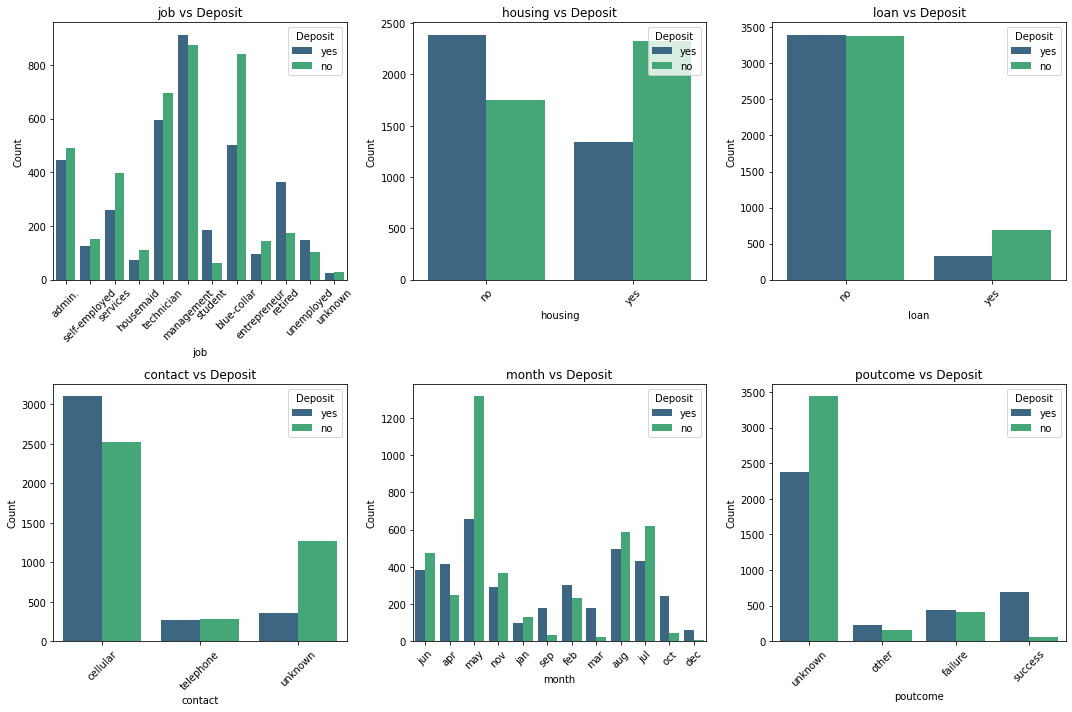

In [20]:
categorical_features = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

# Bar charts for each categorical feature
for i, feature in enumerate(categorical_features):
    sns.countplot(data=df, x=feature, hue='deposit', palette='viridis', ax=axes[i])
    axes[i].set_title(f'{feature} vs Deposit')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Deposit', loc='upper right')
plt.tight_layout()
plt.show()

- Job vs Deposit : Management, technicians, and admin jobs have higher deposits, while blue-collar and self-employed groups show lower subscription rates.
- Housing Loan vs Deposit : Customers without housing loans are more likely to subscribe, possibly due to having more disposable income.
- Personal Loan vs Deposit : No strong impact; most customers do not have personal loans, making this feature less predictive.
- Contact Method vs Deposit : Cellular contact is the most effective, while telephone contact has low conversions.
- Month vs Deposit : March, May, and August show higher deposits, while September and December perform poorly.
- Previous Campaign Outcome vs Deposit : Customers with past successful campaigns have the highest likelihood of subscribing again.

### **Check for Outliers**

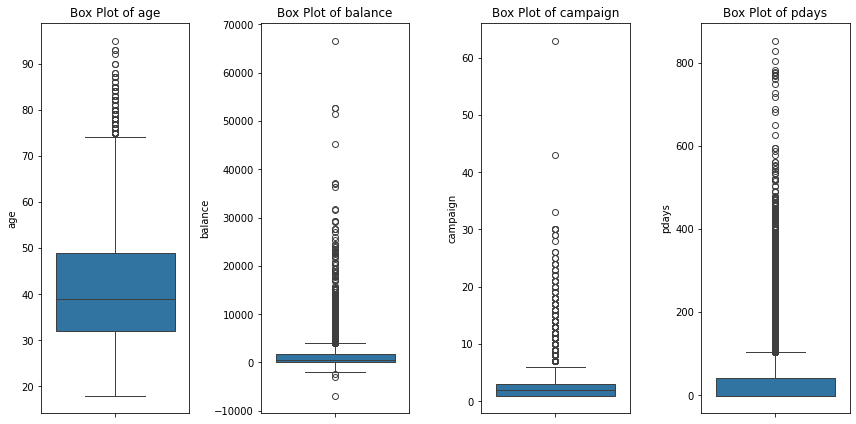

In [21]:
# Check for outlier
numerical_features = ['age', 'balance', 'campaign', 'pdays']

plt.figure(figsize=(12, 6))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(1, len(numerical_features), i)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()


Outliers should be retained in this dataset as they represent valid real-world scenarios rather than errors. For instance, older individuals in the `age` feature or customers with exceptionally high `balance` values could indicate unique but important subsets of the population, such as retirees or high-net-worth clients. Similarly, high values in `campaign` and `pdays` might reflect specific marketing strategies or customer behaviors that could provide critical insights for decision-making.

## **3. Feature Engineering**

Feature engineering transforms raw data into features that improve model performance.

In [22]:
df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


### **1. Deriving `previous_contact` feature**

A value of '-1' in `pdays` indicates the customer was not previously contacted, which can be a significant predictor of deposit behavior. First we set pdays=-1 to zero. Then we create binary feature where :

- 1 → The customer was previously contacted (pdays > 0).
- 0 → The customer was not previously contacted (pdays = 0).

In [23]:
df['pdays'].value_counts()

pdays
-1      5809
 92       80
 91       62
 182      61
 181      56
        ... 
 375       1
 320       1
 373       1
 24        1
 155       1
Name: count, Length: 422, dtype: int64

In [24]:
df[df['pdays'] == 0]

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit


In [25]:
# Replace -1 in pdays with 0
df['pdays'] = df['pdays'].replace(-1, 0)

In [26]:
# Create a binary feature for previous contact
df['previous_contact'] = (df['pdays'] != 0).astype(int)

col_to_move = df.pop('previous_contact')
df.insert(df.columns.get_loc('pdays') + 1, col_to_move.name, col_to_move)

In [27]:
df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,0,0,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,0,0,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,1,other,yes
3,38,services,-87,yes,no,cellular,may,1,0,0,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,0,0,unknown,no


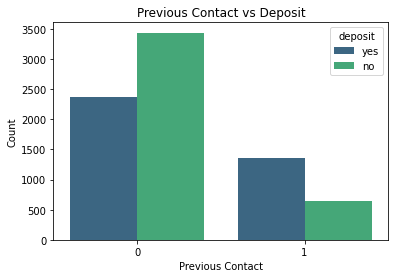

In [28]:
sns.countplot(data=df, x='previous_contact', hue='deposit', palette='viridis')
plt.title('Previous Contact vs Deposit')
plt.xlabel('Previous Contact')
plt.ylabel('Count')
plt.show()

Customers previously contacted in past campaigns (1) are more likely to subscribe, while those without prior contact (0) tend to decline, highlighting the importance of follow-ups in marketing.

### **2. Create `has_loan` status**

Having a housing loan or a personal loan might influence deposit decisions. Combining them can capture the financial burden more effectively.

In [29]:
# Set housing an dloan to 0,1
df['housing'] = df['housing'].map({'yes': 1, 'no': 0})
df['loan'] = df['loan'].map({'yes': 1, 'no': 0})

In [30]:
# Combine housing and loan
df['has_loan'] = ((df['housing'] == 1) | (df['loan'] == 1)).astype(int)

col_to_move = df.pop('has_loan')
df.insert(df.columns.get_loc('loan') + 1, col_to_move.name, col_to_move)

In [31]:
df.head()

,age,job,balance,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,admin.,1662,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,self-employed,-3058,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,admin.,3025,0,0,0,cellular,may,1,352,1,other,yes
3,38,services,-87,1,0,1,cellular,may,1,0,0,unknown,no
4,36,housemaid,205,1,0,1,telephone,nov,4,0,0,unknown,no


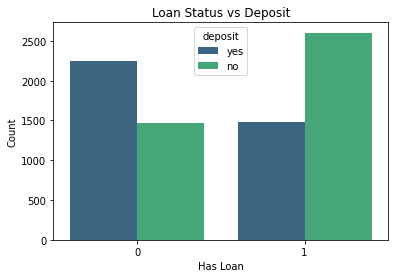

In [32]:
sns.countplot(data=df, x='has_loan', hue='deposit', palette='viridis')
plt.title('Loan Status vs Deposit')
plt.xlabel('Has Loan')
plt.ylabel('Count')
plt.show()

Customers without loans are more likely to subscribe to a deposit, while those with loans tend to decline, suggesting financial obligations impact deposit decisions.

### **3. Binning `age` into Groups**

Age is a continuous variable, but binning it into age groups can simplify analysis and reveal trends across different demographics.

In [33]:
df['age'].describe()

count    7805.000000
mean       41.257783
std        11.922833
min        18.000000
25%        32.000000
50%        39.000000
75%        49.000000
max        95.000000
Name: age, dtype: float64

In [34]:
# Binning age into categories
bins = [18, 30, 40, 60, 100]
labels = ['<30', '30-40', '41-60', '>60']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

col_to_move = df.pop('age_group')
df.insert(df.columns.get_loc('age') + 1, col_to_move.name, col_to_move)
df.head()

,age,age_group,job,balance,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,41-60,admin.,1662,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,30-40,self-employed,-3058,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,41-60,admin.,3025,0,0,0,cellular,may,1,352,1,other,yes
3,38,30-40,services,-87,1,0,1,cellular,may,1,0,0,unknown,no
4,36,30-40,housemaid,205,1,0,1,telephone,nov,4,0,0,unknown,no


In [35]:
df.head()

,age,age_group,job,balance,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,41-60,admin.,1662,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,30-40,self-employed,-3058,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,41-60,admin.,3025,0,0,0,cellular,may,1,352,1,other,yes
3,38,30-40,services,-87,1,0,1,cellular,may,1,0,0,unknown,no
4,36,30-40,housemaid,205,1,0,1,telephone,nov,4,0,0,unknown,no


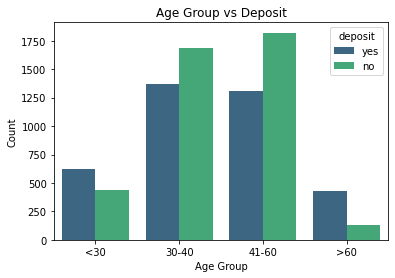

In [36]:
sns.countplot(data=df, x='age_group', hue='deposit', palette='viridis')
plt.title('Age Group vs Deposit')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

Middle-aged groups (30-40 and 41-60) are more likely to subscribe to a deposit, while younger (<30) and older (>60) customers show lower engagement, possibly due to financial priorities.

### **4. Categorize `balance` into Groups**

Customer balances vary widely, and grouping them can make the feature more interpretable and reduce noise.

In [37]:
df['balance'].describe()

count     7805.000000
mean      1513.968225
std       3090.508938
min      -6847.000000
25%        128.000000
50%        550.000000
75%       1685.000000
max      66653.000000
Name: balance, dtype: float64

In [38]:
# Define balance bins and labels
balance_bins = [-float('inf'), 0, 500, 2000, float('inf')]
balance_labels = ['<0', '0-500', '500-2000', '>2000']

# Create a new feature for balance categories
df['balance_category'] = pd.cut(df['balance'], bins=balance_bins, labels=balance_labels, right=False)

col_to_move = df.pop('balance_category')
df.insert(df.columns.get_loc('balance') + 1, col_to_move.name, col_to_move)
df.head()


,age,age_group,job,balance,balance_category,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,41-60,admin.,1662,500-2000,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,30-40,self-employed,-3058,<0,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,41-60,admin.,3025,>2000,0,0,0,cellular,may,1,352,1,other,yes
3,38,30-40,services,-87,<0,1,0,1,cellular,may,1,0,0,unknown,no
4,36,30-40,housemaid,205,0-500,1,0,1,telephone,nov,4,0,0,unknown,no


In [39]:
df.head()

,age,age_group,job,balance,balance_category,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,41-60,admin.,1662,500-2000,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,30-40,self-employed,-3058,<0,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,41-60,admin.,3025,>2000,0,0,0,cellular,may,1,352,1,other,yes
3,38,30-40,services,-87,<0,1,0,1,cellular,may,1,0,0,unknown,no
4,36,30-40,housemaid,205,0-500,1,0,1,telephone,nov,4,0,0,unknown,no


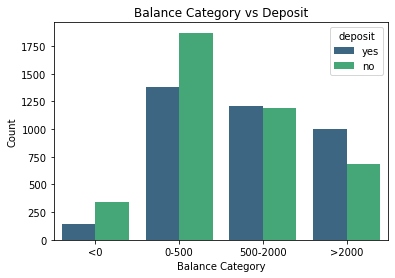

In [40]:
sns.countplot(data=df, x='balance_category', hue='deposit', palette='viridis')
plt.title('Balance Category vs Deposit')
plt.xlabel('Balance Category')
plt.ylabel('Count')
plt.show()

Customers with higher balances (>0) are more likely to subscribe to a deposit, while those with low or negative balances tend to decline, indicating financial stability influences decision-making.

## **4. Data Preparation**

Now we outlines the steps taken to prepare the dataset for modeling, including defining the features (X) and target (y), splitting the data into training and testing sets, and preprocessing (imputation, encoding, and scaling) using a Pipeline and ColumnTransformer.

In [41]:
df_fe = df.copy()
df_fe

,age,age_group,job,balance,balance_category,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,41-60,admin.,1662,500-2000,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,30-40,self-employed,-3058,<0,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,41-60,admin.,3025,>2000,0,0,0,cellular,may,1,352,1,other,yes
3,38,30-40,services,-87,<0,1,0,1,cellular,may,1,0,0,unknown,no
4,36,30-40,housemaid,205,0-500,1,0,1,telephone,nov,4,0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7808,62,>60,housemaid,2,0-500,0,0,0,cellular,nov,1,0,0,unknown,yes
7809,48,41-60,housemaid,5473,>2000,0,0,0,cellular,feb,2,184,1,success,yes
7810,36,30-40,unknown,179,0-500,0,0,0,cellular,aug,8,0,0,unknown,no
7811,31,30-40,admin.,54,0-500,1,0,1,cellular,nov,1,0,0,unknown,no


In [42]:
# # Export df_fe as csv
# df_fe.to_csv('/content/drive/MyDrive/JCDS/Capstone 3/df_fe.csv', index=False)

# # Load df_fe
# df_fe = pd.read_csv('/content/drive/MyDrive/JCDS/Capstone 3/df_fe.csv')

### **1. Define X and y**

The target variable is deposit (whether a customer subscribed to a term deposit).

Features (X) include all columns except the target.

In [43]:
X = df_fe.drop(columns=['deposit'])
y = df_fe['deposit'].map({'yes': 1, 'no': 0})

In [44]:
X.head()

,age,age_group,job,balance,balance_category,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome
0,55,41-60,admin.,1662,500-2000,0,0,0,cellular,jun,2,0,0,unknown
1,39,30-40,self-employed,-3058,<0,1,1,1,cellular,apr,3,0,0,unknown
2,51,41-60,admin.,3025,>2000,0,0,0,cellular,may,1,352,1,other
3,38,30-40,services,-87,<0,1,0,1,cellular,may,1,0,0,unknown
4,36,30-40,housemaid,205,0-500,1,0,1,telephone,nov,4,0,0,unknown


In [45]:
y

0       1
1       1
2       1
3       0
4       0
       ..
7808    1
7809    1
7810    0
7811    0
7812    1
Name: deposit, Length: 7805, dtype: int64

### **2. Train & Test splitting**

The dataset is split into training and test sets with an 80:20 ratio to evaluate model performance.

The random state is set to 42 and using stratified on `y` target variable to ensures that the proportions of the target variable (y) in the train and test sets reflect its distribution in the original dataset.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [47]:
y.value_counts() / len(y)

deposit
0    0.522101
1    0.477899
Name: count, dtype: float64

The dataset is slightly imbalanced (52.2% no deposit, 47.8% deposit), meaning class distribution is relatively even.

### **3. Preprocessing (Pipelines & ColumnTransformer)**

Next step is to prepares data for machine learning by applying different preprocessing steps to numerical, ordinal, and nominal categorical features using pipelines.

1. Numerical Feature Processing (numerical_pipeline)
    - Missing values are filled using the median (SimpleImputer(strategy='median')).
    - Scaling is applied using RobustScaler(), which is resistant to outliers.

2. Ordinal Feature Processing (ordinal_encode)
    - Manually encodes the age_group column using Label Encoding, converting categories into ordered numerical values.

3. Nominal Feature Processing (nominal_pipeline)
    - Fills missing values with the most frequent category (SimpleImputer(strategy='most_frequent')).
    - Applies One-Hot Encoding (OneHotEncoder(drop='first')), converting categorical values into binary columns while dropping the first category to avoid multicollinearity.

4. Combining Everything (ColumnTransformer)
    - Applies numerical transformations to numerical_features.
    - Applies categorical transformations to nominal_features.


In [48]:
df.head()

,age,age_group,job,balance,balance_category,housing,loan,has_loan,contact,month,campaign,pdays,previous_contact,poutcome,deposit
0,55,41-60,admin.,1662,500-2000,0,0,0,cellular,jun,2,0,0,unknown,yes
1,39,30-40,self-employed,-3058,<0,1,1,1,cellular,apr,3,0,0,unknown,yes
2,51,41-60,admin.,3025,>2000,0,0,0,cellular,may,1,352,1,other,yes
3,38,30-40,services,-87,<0,1,0,1,cellular,may,1,0,0,unknown,no
4,36,30-40,housemaid,205,0-500,1,0,1,telephone,nov,4,0,0,unknown,no


In [49]:
# Define numerical and categorical features
numerical_features = ['age', 'balance', 'campaign', 'pdays', 'housing', 'loan']
ordinal_feature = ['age_group']
nominal_features = ['job', 'balance_category', 'contact', 'month', 'poutcome']

# Numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Manually encode the ordinal feature (Label Encoding)
def ordinal_encode(df, feature):
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature])
    return df

df = ordinal_encode(df, 'age_group')

# Categorical pipeline for nominal features
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

# Combine pipelines using ColumnTransformer
transformer = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),  # Numerical pipeline
    ('cat', nominal_pipeline, nominal_features)  # Categorical pipeline
])

## **5. Modeling**

### **1. Cross Validation (Initial Modeling)**

Next step is to evaluates multiple models using 5-fold cross-validation with F1-score as the metric.
- Defines Machine Learning Models (Logistic Regression, Decision Tree, KNN, Random Forest, AdaBoost, Gradient Boosting, XGBoost).
- Creates a Pipeline that applies preprocessing (transformer) before training each model.
- Performs Cross-Validation (cross_val_score) on each model to get mean F1-score and standard deviation for comparison.
- Stores & Prints Results, showing which model performs best.

In [50]:
# Define model (Logistic Regression, Decision Tree, K-Neighbour, Random Forest,
# AdaBoost, Gradient Boosting, XGBoost and LightGBM)

logreg = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)

In [51]:
list_model = [logreg, dt, knn, rf, ada, gb, xgb]
model_names = ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors',
               'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost']
list_all_score = []
list_mean_score = []
list_std = []

# Cross-validation loop
for model, name in zip(list_model, model_names):
    # Create pipeline with preprocessing and model
    pipe_prep_model_initial = Pipeline([
        ('preprocessing', transformer),
        ('modeling', model)
    ])

    # Perform cross-validation
    crossval = cross_val_score(estimator=pipe_prep_model_initial,
                               X=X_train,
                               y=y_train,
                               cv=5,
                               n_jobs=-1,
                               scoring='f1')  # Scoring metric

    # Store results
    list_all_score.append(crossval.round(2))
    list_mean_score.append(crossval.mean())
    list_std.append(crossval.std())

    # Print results for each model
    print(f'{name}: Mean F1 = {crossval.mean():.4f}, Std = {crossval.std():.4f}')

Logistic Regression: Mean F1 = 0.6561, Std = 0.0109
Decision Tree: Mean F1 = 0.6151, Std = 0.0202
K-Nearest Neighbors: Mean F1 = 0.6385, Std = 0.0057
Random Forest: Mean F1 = 0.6764, Std = 0.0108
AdaBoost: Mean F1 = 0.6583, Std = 0.0070
Gradient Boosting: Mean F1 = 0.6798, Std = 0.0154
XGBoost: Mean F1 = 0.6744, Std = 0.0181


In [52]:
df_f1_initial = pd.DataFrame()
df_f1_initial['algorithm_model'] = list_model
df_f1_initial['all_f1_score'] = list_all_score
df_f1_initial['mean_f1_score'] = list_mean_score
df_f1_initial['std_score'] = list_std

df_f1_initial.sort_values(by = 'mean_f1_score', ascending=False)

,algorithm_model,all_f1_score,mean_f1_score,std_score
5,GradientBoostingClassifier(random_state=42),"[0.67, 0.68, 0.71, 0.66, 0.68]",0.679788,0.015387
3,RandomForestClassifier(random_state=42),"[0.66, 0.68, 0.69, 0.68, 0.68]",0.676428,0.010756
6,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n gamma=None, grow_policy=None, importance_type=None,\n interaction_constraints=None, learning_rate=None, max_bin=None,\n max_cat_threshold=None, max_cat_to_onehot=None,\n max_delta_step=None, max_depth=None, max_leaves=None,\n min_child_weight=None, missing=nan, monotone_constraints=None,\n multi_strategy=None, n_estimators=None, n_jobs=None,\n num_parallel_tree=None, random_state=42, ...)","[0.64, 0.68, 0.68, 0.69, 0.68]",0.674450,0.018073
4,AdaBoostClassifier(random_state=42),"[0.65, 0.66, 0.67, 0.66, 0.65]",0.658347,0.006978
0,"LogisticRegression(max_iter=1000, random_state=42)","[0.64, 0.66, 0.67, 0.64, 0.66]",0.656052,0.010867
2,KNeighborsClassifier(),"[0.65, 0.63, 0.64, 0.63, 0.64]",0.638464,0.005681
1,DecisionTreeClassifier(random_state=42),"[0.6, 0.61, 0.64, 0.64, 0.59]",0.615062,0.020226


From all the initial cross validation modeling with 5 folds from these 7 classification models, Gradient Boosting Achieved the highest mean score of f1-score at 67.9%, followed by RandomForestClassifier at 67.6%.

### **2.1. Hyperparameter Tuning**

Nest is to perform hyperparameter tuning setup on multiple machine learning models along with their hyperparameter grids for tuning using RandomizedSearchCV.

Each model has a custom hyperparameter grid to optimize performance:
- Logistic Regression → Tunes regularization strength (C) and solver type.
- Decision Tree & Random Forest → Tunes tree depth (max_depth), splitting criteria (gini/entropy), and number of splits/leaves.
- K-Nearest Neighbors (KNN) → Tunes number of neighbors (n_neighbors), distance metric (euclidean/manhattan).
- Boosting Models (AdaBoost, Gradient Boosting, XGBoost) → Tunes number of estimators (n_estimators), learning rate, and depth of trees.
- XGBoost → Additionally tunes gamma (regularization for splits).

In [ ]:
# Define models with hyperparameters
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'param_grid': {
            'model__C': np.logspace(-4, 4, 20),
            'model__penalty': ['l1', 'l2'],
            'model__solver': ['liblinear', 'saga']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'model__max_depth': [10, 20, 30, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 5, 10],
            'model__criterion': ['gini', 'entropy']
        }
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'model__n_neighbors': range(3, 15),
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'param_grid': {
            'model__n_estimators': [100, 300, 500],
            'model__max_depth': [10, 20, 30, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 5, 10],
            'model__criterion': ['gini', 'entropy']
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'param_grid': {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.001, 0.01, 0.1, 1, 10],
            'model__algorithm': ['SAMME', 'SAMME.R'],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'param_grid': {
            'model__n_estimators': [100, 300, 500],
            'model__learning_rate': [0.001, 0.01, 0.1, 1, 10],
            'model__max_depth': [3, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'param_grid': {
            'model__n_estimators': [100, 300, 500],
            'model__learning_rate': [0.001, 0.01, 0.1, 1, 10],
            'model__max_depth': [3, 5, 10],
            'model__gamma': [0, 0.1, 0.2]
        }
    }
}

In [54]:
# Store results in a list
results = []

# Stratified K-Fold for consistent class distribution
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through all models and perform hyperparameter tuning
for model_name, config in models.items():
    print(f"\nTuning hyperparameters for: {model_name}")

    # Define pipeline with preprocessing and model
    pipeline = Pipeline(steps=[
        ('preprocessing', transformer),
        ('model', config['model'])
    ])

    # Set up RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['param_grid'],
        n_iter=50,  # Number of random samples
        cv=stratified_kfold,  # Stratified K-Fold
        scoring='f1',
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    # Fit RandomizedSearchCV
    random_search.fit(X_train, y_train)

    # Store best results
    results.append({
        'algorithm_model': model_name,
        'best_params': random_search.best_params_,
        'best_f1_score': random_search.best_score_
    })

# Convert results to DataFrame
df_f1_hypertuned = pd.DataFrame(results)


Tuning hyperparameters for: Logistic Regression
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning hyperparameters for: Decision Tree
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning hyperparameters for: K-Nearest Neighbors
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Tuning hyperparameters for: Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning hyperparameters for: AdaBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning hyperparameters for: Gradient Boosting
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Tuning hyperparameters for: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [87]:
df_f1_hypertuned.sort_values(by='best_f1_score', ascending = False)

,algorithm_model,best_params,best_f1_score
3,Random Forest,"{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None, 'model__criterion': 'gini'}",0.684236
6,XGBoost,"{'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.2}",0.677560
5,Gradient Boosting,"{'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}",0.675057
4,AdaBoost,"{'model__n_estimators': 200, 'model__learning_rate': 1, 'model__algorithm': 'SAMME'}",0.668282
0,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 0.08858667904100823}",0.664111
2,K-Nearest Neighbors,"{'model__weights': 'distance', 'model__n_neighbors': 13, 'model__metric': 'manhattan'}",0.659717
1,Decision Tree,"{'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_depth': 20, 'model__criterion': 'gini'}",0.646480


After hyperparameter tuning, the highest f1-score is achieved by RandomForestClassifier at 68.42%

### **2.2. Hyperparameter Tuning using SMOTE**

Next step is to performs hyperparameter tuning on multiple models while applying SMOTE to handle class imbalance.

- Applies SMOTE (sampling_strategy='auto') to balance the dataset.
- Uses RandomizedSearchCV for hyperparameter tuning.
- Performs 5-fold Stratified K-Fold Cross-Validation to ensure fair evaluation.
- Finds the best model parameters while accounting for class imbalance.

In [ ]:
# Store results
results = []

# Stratified K-Fold to maintain class distribution
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through models and apply SMOTE
for model_name, config in models.items():
    print(f"\nTuning with Light SMOTE for: {model_name}")

    # Define pipeline with SMOTE and model
    pipeline = Pipeline(steps=[
        ('preprocessing', transformer),  # Preprocessing pipeline
        ('sampling', SMOTE(sampling_strategy='auto', random_state=42)),  #SMOTE
        ('model', config['model'])  # Model
    ])

    # Set up RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['param_grid'],
        n_iter=50,  # Number of random samples
        cv=stratified_kfold,  # Stratified K-Fold for better class handling
        scoring='f1',
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    # Fit model with Light SMOTE
    random_search.fit(X_train, y_train)

    # Store best results
    results.append({
        'algorithm_model': model_name,
        'best_params': random_search.best_params_,
        'best_f1_score': random_search.best_score_
    })

# Convert results to DataFrame
df_f1_hypertuned_light_smote = pd.DataFrame(results)


Tuning with Light SMOTE for: Logistic Regression
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning with Light SMOTE for: Decision Tree
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning with Light SMOTE for: K-Nearest Neighbors
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Tuning with Light SMOTE for: Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning with Light SMOTE for: AdaBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning with Light SMOTE for: Gradient Boosting
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Tuning with Light SMOTE for: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [90]:
df_f1_hypertuned_light_smote.sort_values(by = 'best_f1_score', ascending = False)

,algorithm_model,best_params,best_f1_score
3,Random Forest,"{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 20, 'model__criterion': 'entropy'}",0.690193
6,XGBoost,"{'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.2}",0.684037
5,Gradient Boosting,"{'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.1}",0.681092
4,AdaBoost,"{'model__n_estimators': 100, 'model__learning_rate': 1, 'model__algorithm': 'SAMME'}",0.678494
0,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 0.08858667904100823}",0.674749
2,K-Nearest Neighbors,"{'model__weights': 'uniform', 'model__n_neighbors': 13, 'model__metric': 'euclidean'}",0.664318
1,Decision Tree,"{'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_depth': 10, 'model__criterion': 'entropy'}",0.647338


After hyperparameter tuning and applying SMOTE resampling to address imbalance, the highest f1-score is achieved by RandomForestClassifier at 69.01%. We will now proceed using this model.

### **2.3. Further Hyperparamater Tuning (+SMOTE) on Random Forest Model**
Using the best performing models as well as its parameter, next is to do a further parameter tuning as well as model's evaluation on full training sets. Using the parameters from before as the starting points

In [58]:
# Extract the best Random Forest parameters from df_f1_hypertuned_light_smote
rf_best_row = df_f1_hypertuned_light_smote[df_f1_hypertuned_light_smote['algorithm_model'] == 'Random Forest']
best_rf_params = rf_best_row['best_params'].values[0]

# Convert dictionary keys to match sklearn syntax (if needed)
best_rf_params = {key.replace('model__', ''): value for key, value in best_rf_params.items()}
best_rf_params

{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_depth': 20,
 'criterion': 'entropy'}

In [59]:
# Define the new parameter grid
param_grid = {
    'model__n_estimators': [300, 400, 500],
    'model__min_samples_split': [10, 15, 20, 25],
    'model__min_samples_leaf': [1, 2, 3, 4],
    'model__max_depth': [20, 25, 30],
    'model__criterion': ['entropy']
}

# Create a pipeline with preprocessing, SMOTE, and Random Forest
rf_pipeline_smote = Pipeline(steps=[
    ('preprocessing', transformer),
    ('smote', SMOTE(random_state=42)),  # Apply SMOTE
    ('model', RandomForestClassifier(**best_rf_params, random_state=42))  # Use best params
])

In [60]:
# Run RandomizedSearchCV
random_search_smote = RandomizedSearchCV(
    estimator=rf_pipeline_smote,
    param_distributions=param_grid,
    n_iter=200,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fitting with best params + SMOTE
random_search_smote.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['age',
                                                                                'balance',
                                                                                'campaign',
                                                                                'pdays',
                                                                                'housing',
                                                                                'loan']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(d...
                                              RandomForestClassifier(criterion='entropy',
                                                                     max_depth=20,
                                                                     min_samples_split=10,
                                                                     n_estimators=300,
                                                                     random_state=42))]),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'model__criterion': ['entropy'],
                                        'model__max_depth': [20, 25, 30],
                                        'model__min_samples_leaf': [1, 2, 3, 4],
                                        'model__min_samples_split': [10, 15, 20,
                                                                     25],
                                        'model__n_estimators': [300, 400, 500]},
                   random_state=42, scoring='f1', verbose=1)

In [61]:
# Extract the best estimator
best_rf_smote = random_search_smote.best_estimator_

# Print results
print("Best Parameters:", random_search_smote.best_params_)
print("Best F1-Score with SMOTE:", random_search_smote.best_score_)

Best Parameters: {'model__n_estimators': 400, 'model__min_samples_split': 15, 'model__min_samples_leaf': 2, 'model__max_depth': 20, 'model__criterion': 'entropy'}
Best F1-Score with SMOTE: 0.6905792270442411


In [62]:
# Save the trained model with preprocessing
joblib.dump(best_rf_smote, "best_rf_smote.pkl")
print("Best Random Forest pipeline saved as 'best_rf_smote.pkl'")

Best Random Forest pipeline saved as 'best_rf_smote.pkl'


In [63]:
# Load the saved pipeline
best_rf_smote = joblib.load("best_rf_smote.pkl")

### **3. Evaluation on Test Data**

In [154]:
# Train the model on the full training set
best_rf_smote.fit(X_train, y_train)

# Make predictions
y_pred = best_rf_smote.predict(X_test)
y_proba = best_rf_smote.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Print classification report
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred, digits=4))

# Store results in a DataFrame
rf_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [accuracy, precision, recall, f1, roc_auc]
})

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0     0.7169    0.8110    0.7611       815
           1     0.7590    0.6501    0.7004       746

    accuracy                         0.7341      1561
   macro avg     0.7380    0.7306    0.7307      1561
weighted avg     0.7370    0.7341    0.7321      1561



- Precision is balanced (0.7169 vs. 0.7590) → The model is confident in its predictions.
- Recall for Deposits (0.6501).
- Overall F1-score (0.7321) shows a strong balance between precision & recall.

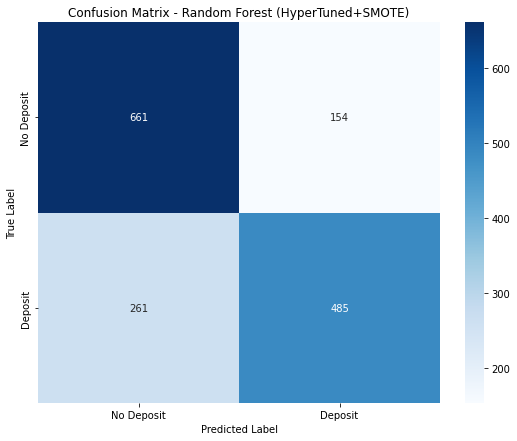

In [114]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest (HyperTuned+SMOTE)")
plt.show()

- False Negatives (261 cases) → Some deposit customers were missed, but recall is still better than before.
- False Positives (154 cases) → Some non-deposit customers were predicted incorrectly.
- True Positives (485 cases) → The model successfully identified 485 deposit customers.
- True Negatives (661 cases) → The model successfully identified 661 non-deposit customers.

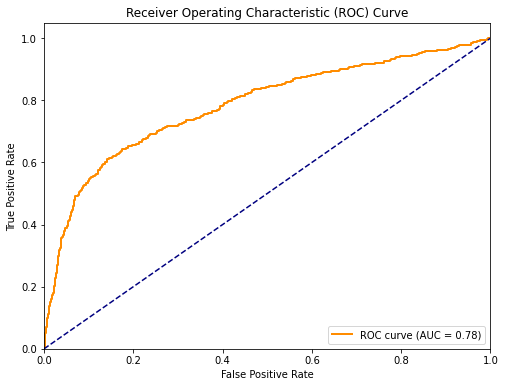

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

The model’s ROC curve showing the trade-off between sensitivity (recall) and specificity.

- UC = 0.78 → The model is 78% likely to rank a randomly chosen positive instance higher than a negative one..
- Higher AUC = Better Model (AUC close to 1 is ideal).

Precision-Recall (PR) Curve helps find the best threshold to balance precision and recall

### **4. Feature Importance Analysis**


In [72]:
# Extract feature importance from the trained Random Forest model
feature_importances = best_rf_smote.named_steps['model'].feature_importances_

# Get feature names from the ColumnTransformer
feature_names = best_rf_smote.named_steps['preprocessing'].get_feature_names_out()

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display top features
importance_df.head(20).sort_values(by='Importance', ascending=False)

,Feature,Importance
1,num__balance,0.136457
0,num__age,0.131841
34,cat__poutcome_success,0.087894
21,cat__contact_unknown,0.079725
3,num__pdays,0.074497
2,num__campaign,0.071741
4,num__housing,0.049104
35,cat__poutcome_unknown,0.028005
27,cat__month_jun,0.025157
5,num__loan,0.025056


- num_balance (13.64%) and num_age (13.18%) are the most influential features, indicating that a customer’s account balance and age significantly impact deposit subscriptions.
- cat_poutcome_success (8.78%) → If a customer’s previous campaign was successful, they are more likely to subscribe again.
- cat_contact_unknown (7.97%) → The type of contact method also influences the prediction.

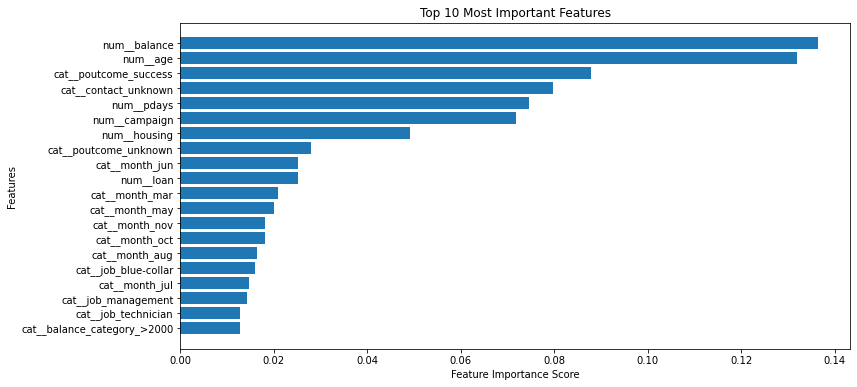

In [73]:
# Plot Feature Importance
plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'].head(20), importance_df['Importance'].head(20))
plt.gca().invert_yaxis()  # Highest importance at the top
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features")
plt.show()

- The bar chart visually confirms the dominance of num_balance and num_age as top predictive factors.
- Previous campaign outcomes (cat_poutcome_success) are critical, reinforcing the idea that past campaign success improves future deposit conversions.

### **5. Threshold Optimization**

In [159]:
# Define a range of thresholds (from 0.1 to 0.9)
thresholds = np.arange(0.1, 1.0, 0.001)

# Store evaluation metrics
results = []

for threshold in thresholds:
    y_pred_adjusted = (y_proba >= threshold).astype(int)

    # Compute metrics
    recall = recall_score(y_test, y_pred_adjusted)
    precision = precision_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    accuracy = accuracy_score(y_test, y_pred_adjusted)

    # Store the results
    results.append((threshold, recall, precision, f1, accuracy))

# Convert results to DataFrame
import pandas as pd
df_thresholds = pd.DataFrame(results, columns=['Threshold', 'Recall', 'Precision', 'F1-Score', 'Accuracy'])

# Display thresholds sorted by F1-score
df_thresholds.sort_values(by='F1-Score', ascending=False).head()

,Threshold,Recall,Precision,F1-Score,Accuracy
263,0.363,0.835121,0.619284,0.711187,0.675849
264,0.364,0.835121,0.619284,0.711187,0.675849
261,0.361,0.837802,0.617589,0.711035,0.674568
265,0.365,0.832440,0.619760,0.710526,0.675849
262,0.362,0.835121,0.618056,0.710376,0.674568


In [140]:
best_threshold = round(df_thresholds.loc[df_thresholds['F1-Score'].idxmax(), 'Threshold'],5)
print("Best Threshold:", best_threshold)

Best Threshold: 0.363


- The best threshold is 0.36, achieving an F1-score of 0.7112 (highlighted in the table).
- Higher Recall (0.8351) at Threshold = 0.36 indicates the model correctly identifies more deposit customers.
- Precision (0.6192) decreases slightly at lower thresholds because the model predicts more positive cases (Deposits), leading to more False Positives.

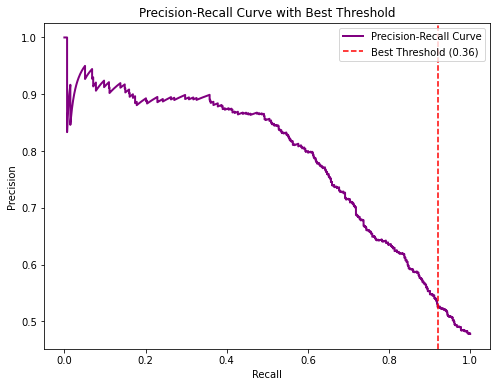

In [141]:
# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='purple', lw=2, label="Precision-Recall Curve")

# Add a vertical line at the best threshold
plt.axvline(x=recall_vals[(thresholds >= best_threshold).argmax()], 
            color='red', linestyle='--', label=f"Best Threshold (0.36)")

# Labels and Title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Best Threshold")
plt.legend(loc="upper right")

# Show plot
plt.show()

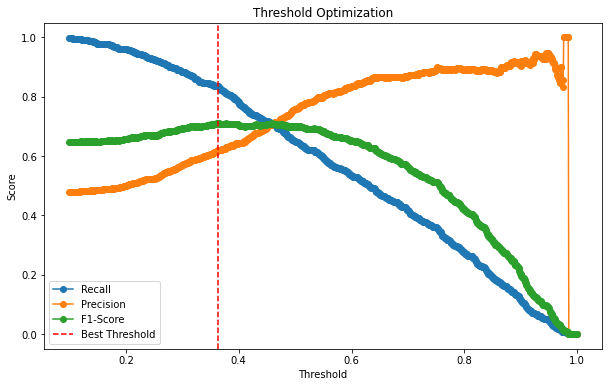

In [142]:
plt.figure(figsize=(10,6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], label='Recall', marker='o')
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], label='Precision', marker='o')
plt.plot(df_thresholds['Threshold'], df_thresholds['F1-Score'], label='F1-Score', marker='o')

plt.axvline(x=best_threshold, color='r', linestyle='--', label='Best Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization')
plt.legend()
plt.show()

- The curve shows the trade-off → As recall increases, precision decreases.
- Best Threshold (0.36) is marked with a red dashed line → This is where the F1-score is maximized.

- At 0.36 threshold:
    - High recall (~0.8351) → More deposit customers correctly identified.
    - Slightly lower precision (~0.6192) → More false positives

### **6. Final Model Evaluation**

#### Modeling using Default Random Forest

In [165]:
# Define and Train Default Random Forest Model
rf_default = Pipeline(steps=[
    ('preprocessing', transformer),
    ('model', RandomForestClassifier(random_state=42))
])

rf_default.fit(X_train, y_train)  # Train the model

# Predictions
y_pred_default = rf_default.predict(X_test)
y_proba_default = rf_default.predict_proba(X_test)[:, 1]

# Compute Metrics
default_accuracy = accuracy_score(y_test, y_pred_default)
default_recall = recall_score(y_test, y_pred_default)
default_precision = precision_score(y_test, y_pred_default)
default_f1 = f1_score(y_test, y_pred_default)

# Print Evaluation Metrics
print(f"Default Random Forest Model Performance:")
print(f"Accuracy: {default_accuracy:.4f}")
print(f"Precision: {default_precision:.4f}")
print(f"Recall: {default_recall:.4f}")
print(f"F1-Score: {default_f1:.4f}")

Default Random Forest Model Performance:
Accuracy: 0.7079
Precision: 0.7171
Recall: 0.6421
F1-Score: 0.6775


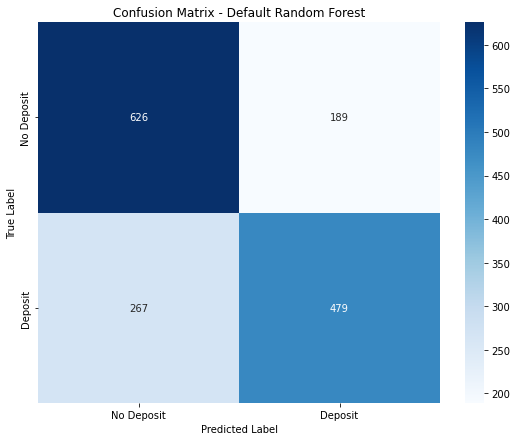

In [167]:
# Compute Confusion Matrix
default_conf_matrix = confusion_matrix(y_test, y_pred_default)

# Plot Confusion Matrix
plt.figure(figsize=(9,7))
sns.heatmap(default_conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Default Random Forest")
plt.show()

#### **Final Model Evaluation using Threshold Optimization**

In [156]:
# Get predicted probabilities for the positive class
y_probs_test = best_rf_smote.predict_proba(X_test)[:, 1]  

# Apply the best threshold (from threshold optimization)
y_pred_final = (y_probs_test >= best_threshold).astype(int)

In [ ]:
# Compute metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

# Print evaluation metrics
print(f"Final Accuracy: {final_accuracy:.4f}")
print(f"Final Recall: {final_recall:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final F1-Score: {final_f1:.4f}")

Final Accuracy: 0.6758
Final Recall: 0.8351
Final Precision: 0.6193
Final F1-Score: 0.7112


- Recall improved significantly (83.51%), meaning more deposit customers were correctly identified.
- Precision decreased slightly (61.93%), meaning more false positives.
- F1-score (71.12%) is balanced, confirming that the model effectively balances Precision & Recall.

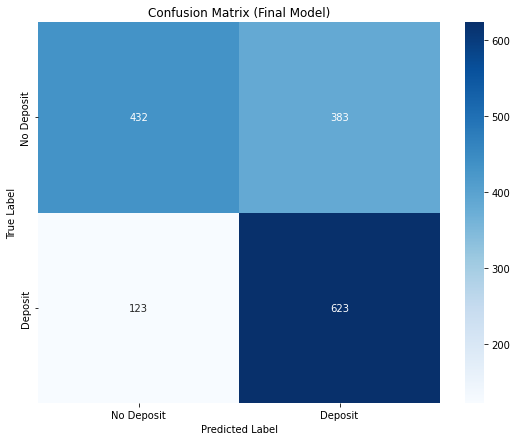

In [163]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_final)

# Plot confusion matrix
plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Deposit", "Deposit"], yticklabels=["No Deposit", "Deposit"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Final Model)")
plt.show()

- More deposit customers are correctly classified → 623 True Positives, meaning the model successfully captures most of them.
- False negatives (missed deposits) are significantly reduced to 123, compared to the default threshold (0.5).
- False positives (383 cases) increased, meaning some non-deposit customers were misclassified as depositors.

## **7. Business Impact Analysis**

**Business Cost-Benefit Analysis: Case for Deposit Prediction**

**Financial Assumptions**
To evaluate the **real-world financial impact** of each model, we use industry-recommended financial values:

- **True Positive (TP) Profit: $1,650** per correctly classified deposit customer  
  - *Source:* Average customer revenue from deposit accounts ([BankDirector](https://www.bankdirector.com/article/the-profitability-of-the-average-checking-account/))
  
- **False Positive (FP) Cost: $396** per mistakenly targeted non-deposit customer  
  - *Source:* Average customer acquisition cost ([FirstPageSage](https://firstpagesage.com/seo-blog/average-customer-acquisition-cost-cac-in-banking/))
  
- **False Negative (FN) Loss: $1,650** per missed deposit customer  
  - *Rationale:* The bank loses the potential revenue from a customer who could have deposited but wasn't targeted.

- **True Negative (TN) Profit: $0** (No impact on profit or loss)
  - No benefit or cost for correctly identifying non-deposit customers.

---
**Cost-Benefit Calculation Formula**

$$
\text{Net Benefit} = (\text{TP} \times \text{Profit per TP}) - (\text{FP} \times \text{Cost per FP}) - (\text{FN} \times \text{Loss per FN}) + (\text{TN} \times \text{Profit per TN})
$$

Each model's **confusion matrix** will be used to calculate its **financial performance**.

---


### **Net Benefit Calculation for Default Random Forest**

In [172]:
# Define financial values
profit_per_tp = 1650   # Profit from a successful deposit
cost_per_fp = 396      # Cost of marketing to an uninterested customer
loss_per_fn = 1650     # Loss of missing a potential deposit
profit_per_tn = 0      # No cost/benefit for true negatives

# Confusion Matrix values (Default Random Forest)
tp_default = 479
fp_default = 189
fn_default = 267
tn_default = 626

# Step-by-step calculations
profit_from_tp = tp_default * profit_per_tp
cost_from_fp = fp_default * cost_per_fp
loss_from_fn = fn_default * loss_per_fn
profit_from_tn = tn_default * profit_per_tn

# Compute Net Benefit
net_benefit_default = profit_from_tp - cost_from_fp - loss_from_fn + profit_from_tn

# Print Breakdown and Results
print("-> Default Random Forest Calculation Breakdown:")
print(f"   Profit from True Positives (TP): {tp_default} × ${profit_per_tp} = ${profit_from_tp:,.2f}")
print(f"   Cost from False Positives (FP): {fp_default} × ${cost_per_fp} = -${cost_from_fp:,.2f}")
print(f"   Loss from False Negatives (FN): {fn_default} × ${loss_per_fn} = -${loss_from_fn:,.2f}")
print(f"   Profit from True Negatives (TN): {tn_default} × ${profit_per_tn} = ${profit_from_tn:,.2f}")
print(f"\n Net Benefit for Default Random Forest: ${net_benefit_default:,.2f}")



-> Default Random Forest Calculation Breakdown:
   Profit from True Positives (TP): 479 × $1650 = $790,350.00
   Cost from False Positives (FP): 189 × $396 = -$74,844.00
   Loss from False Negatives (FN): 267 × $1650 = -$440,550.00
   Profit from True Negatives (TN): 626 × $0 = $0.00

 Net Benefit for Default Random Forest: $274,956.00


### **Net Benefit Calculation for Hypertuned + SMOTE Random Forest**

In [174]:
# Confusion Matrix values (Hypertuned + SMOTE RF)
tp_hypertuned = 485
fp_hypertuned = 154
fn_hypertuned = 261
tn_hypertuned = 661

# Step-by-step calculations
profit_from_tp_hyper = tp_hypertuned * profit_per_tp
cost_from_fp_hyper = fp_hypertuned * cost_per_fp
loss_from_fn_hyper = fn_hypertuned * loss_per_fn
profit_from_tn_hyper = tn_hypertuned * profit_per_tn

# Compute Net Benefit
net_benefit_hypertuned = profit_from_tp_hyper - cost_from_fp_hyper - loss_from_fn_hyper + profit_from_tn_hyper

# Print Breakdown and Results
print("\n-> Hypertuned + SMOTE Random Forest Calculation Breakdown:")
print(f"   Profit from True Positives (TP): {tp_hypertuned} × ${profit_per_tp} = ${profit_from_tp_hyper:,.2f}")
print(f"   Cost from False Positives (FP): {fp_hypertuned} × ${cost_per_fp} = -${cost_from_fp_hyper:,.2f}")
print(f"   Loss from False Negatives (FN): {fn_hypertuned} × ${loss_per_fn} = -${loss_from_fn_hyper:,.2f}")
print(f"   Profit from True Negatives (TN): {tn_hypertuned} × ${profit_per_tn} = ${profit_from_tn_hyper:,.2f}")
print(f"\n Net Benefit for Hypertuned + SMOTE Random Forest: ${net_benefit_hypertuned:,.2f}")


-> Hypertuned + SMOTE Random Forest Calculation Breakdown:
   Profit from True Positives (TP): 485 × $1650 = $800,250.00
   Cost from False Positives (FP): 154 × $396 = -$60,984.00
   Loss from False Negatives (FN): 261 × $1650 = -$430,650.00
   Profit from True Negatives (TN): 661 × $0 = $0.00

 Net Benefit for Hypertuned + SMOTE Random Forest: $308,616.00


### **Net Benefit Calculation for Final Model (Threshold = 0.36)**


In [175]:
# Confusion Matrix values (Final Model with Optimized Threshold)
tp_final = 623
fp_final = 383
fn_final = 123
tn_final = 432

# Step-by-step calculations
profit_from_tp_final = tp_final * profit_per_tp
cost_from_fp_final = fp_final * cost_per_fp
loss_from_fn_final = fn_final * loss_per_fn
profit_from_tn_final = tn_final * profit_per_tn

# Compute Net Benefit
net_benefit_final = profit_from_tp_final - cost_from_fp_final - loss_from_fn_final + profit_from_tn_final

# Print Breakdown and Results
print("\n-> Final Model (Threshold 0.36) Calculation Breakdown:")
print(f"   Profit from True Positives (TP): {tp_final} × ${profit_per_tp} = ${profit_from_tp_final:,.2f}")
print(f"   Cost from False Positives (FP): {fp_final} × ${cost_per_fp} = -${cost_from_fp_final:,.2f}")
print(f"   Loss from False Negatives (FN): {fn_final} × ${loss_per_fn} = -${loss_from_fn_final:,.2f}")
print(f"   Profit from True Negatives (TN): {tn_final} × ${profit_per_tn} = ${profit_from_tn_final:,.2f}")
print(f"\n Net Benefit for Final Model (Threshold 0.36): ${net_benefit_final:,.2f}")



-> Final Model (Threshold 0.36) Calculation Breakdown:
   Profit from True Positives (TP): 623 × $1650 = $1,027,950.00
   Cost from False Positives (FP): 383 × $396 = -$151,668.00
   Loss from False Negatives (FN): 123 × $1650 = -$202,950.00
   Profit from True Negatives (TN): 432 × $0 = $0.00

 Net Benefit for Final Model (Threshold 0.36): $673,332.00


**Cost-Benefit Analysis**
1. Default Random Forest → $274,956 net benefit
    - Decent baseline but loses revenue due to high false negatives (267 missed deposits).

2. Hypertuned + SMOTE → $308,616 net benefit.
    - Slightly better recall (more deposit customers captured) while keeping false positives lower.

3. Final Model (Threshold 0.36) → $673,332 net benefit.
    - Best performance, capturing 623 deposit customers despite more false positives.
    - Maximizes revenue, making it the best model for business impact.

---

**📌 Key Takeaways**
- Hyperparameter tuning improved revenue, but threshold optimization had the biggest gain.
- Final model is 145% more profitable than the default.


## **6. Conclusion and Recommendation**

### **Conclusion:**

1. Data Preprocessing & Feature Engineering
    - Handling missing values, scaling numerical data (RobustScaler), and encoding categorical features (OneHot & Label Encoding) improved model performance.
    - Engineered new features such as age groups, balance categories, and previous contact status to enhance model performance.

2. Exploratory Data Analysis (EDA)
    - Identified class imbalance (47% deposit, 53% no deposit).
    - Found key patterns in age, balance, previous contacts, and job roles impacting deposit decisions.
    - Outliers were detected but retained for model robustness.

3. Feature Importance Analysis
    - Balance and Age were the most important predictors, followed by poutcome, contact type, and campaign count.

4. Modeling & Optimization
    - Baseline Random Forest achieved 67.7% F1-score.
    - Hyperparameter tuning & SMOTE improved recall, reducing false negatives and increasing the number of predicted deposit customers.
    - After hyperparameter tuning, Random Forest achieved the highest F1-score (68.42%).
    - Threshold tuning (0.36) further optimized precision-recall balance, yielding the best business benefit ($673,332).

5. Cost-Benefit Analysis
    - Default Random Forest: $274,956 net benefit.
    - Hypertuned + SMOTE Random Forest: $308,616 net benefit.
    - Final Model (Threshold 0.36): $673,332 net benefit (145% increase from baseline).

### **Recommendations**

1. Deploy the Model (Threshold 0.36) for Maximum Profitability
    - The final Random Forest model with threshold tuning yielded the highest net benefit ($673,332), significantly outperforming the default model.
    - This model captures 623 deposit customers while maintaining a balance between precision and recall.
    - Use this model in marketing campaigns to target potential deposit customers efficiently.

2. Optimize Marketing Efforts to Reduce False Positives
    - The final model increased false positives (383 customers who won’t deposit), leading to higher marketing costs.
    - Focus on customers with high balance and previous successful contact history, as these features showed strong importance in deposit predictions.
    - Gradually increase the decision threshold if reducing unnecessary marketing costs becomes a priority.

3. Prioritize Customer Segments with Higher Deposit Likelihood
    - Customers in the 41-60 age group are the most likely to deposit.
    - Individuals with higher account balances and those previously contacted are more responsive.
    - Allocate more marketing resources toward 41-60 age group customers with high balance.
    - Design personalized offers for customers who have been contacted before but haven’t deposited yet.


4. Monitor and adapt the model based on changing customer behavior to sustain long-term business profitability.
    - Periodically retrain the model with updated customer data to maintain high accuracy.
    - Reassess the optimal decision threshold as the business objective shifts between maximizing deposits and controlling marketing expenses.